# Evaluation — GenAI Recruiter Bot (Epic E5, spec §9)

**Method (per brief):** replay the 15 labeled conversations in `data/raw/sms_conversations.json`;
at every labeled recruiter turn, feed the system the history up to that point (via the real
`app.graph.run_turn`, advisors + SQL/vector access included, `now` = each conversation's own
`start_time_utc`) and record the action the Main Agent chooses; compare to the gold label.

**Determinism:** every advisor/routing decision call uses `temperature=0`
(`settings.decision_temperature`), and every LLM call goes through `app.llm_client.cached_parse`'s
content-addressed disk cache (`.cache/llm/`) — so after the first run, re-running this notebook
top-to-bottom is cheap and reproduces the same numbers.

This notebook reuses `tests/eval_replay.py`'s case-building/replay logic (`_build_cases`,
`_run_case`) rather than duplicating it — that module's pure case-building logic is unit-tested
in `tests/test_eval_replay_cases.py`.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "app").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
ROOT

WindowsPath('C:/Users/robinson.nir/OneDrive - Uniko/GEN AI HANDS ON/GAI PROJECT/genai-recruiter-bot/genai-recruiter-bot')

In [2]:
import json

from tests.eval_replay import CONVERSATIONS_PATH, _build_cases, _run_case

conversations = json.loads(CONVERSATIONS_PATH.read_text(encoding="utf-8"))
cases = [case for conversation in conversations for case in _build_cases(conversation)]
len(cases)

44

## Replay (GRB-050)

Runs every case through the real graph. First run makes real API calls (cached to disk after); reruns are fast/free.

In [3]:
results = []
for i, case in enumerate(cases):
    result = _run_case(case)
    results.append(
        {
            "conversation_id": case["conversation_id"],
            "turn_id": case["turn_id"],
            "trigger": case["trigger"],
            "gold": case["gold"],
            "predicted": result["action"],
            "message": result["message"],
            "trace": result["trace"],
        }
    )
    if (i + 1) % 10 == 0:
        print(f"...{i + 1}/{len(cases)} cases replayed")
print(f"Done: {len(results)} cases replayed.")

...10/44 cases replayed


...20/44 cases replayed


...30/44 cases replayed


...40/44 cases replayed


Done: 44 cases replayed.


In [4]:
import pandas as pd

df = pd.DataFrame(results)
df.head()

,conversation_id,turn_id,trigger,gold,predicted,message,trace
0,1,3,I've been using Python professionally for five...,schedule,schedule,I can offer these interview times: 2024-04-04 ...,"[{'advisor': 'sched', 'decision': 'sched', 're..."
1,1,5,I can't at that time—I'm busy.,schedule,schedule,I can offer these interview times: 2024-04-04 ...,"[{'advisor': 'sched', 'decision': 'sched', 're..."
2,1,7,Monday at 3 PM is good.,end,schedule,I can offer these interview times: 2024-04-09 ...,"[{'advisor': 'sched', 'decision': 'sched', 're..."
3,2,3,I have three years' experience with Django and...,continue,schedule,I can offer these interview times: 2024-05-01 ...,"[{'advisor': 'sched', 'decision': 'sched', 're..."
4,2,5,Could you share more about the company's cloud...,continue,continue,"I'm sorry, but the job description does not pr...","[{'advisor': 'info', 'decision': 'info_needed'..."


## Metrics (GRB-051)

In [5]:
accuracy = (df["gold"] == df["predicted"]).mean()
n_correct = (df["gold"] == df["predicted"]).sum()
print(f"Overall accuracy: {accuracy:.1%} ({n_correct}/{len(df)})")

Overall accuracy: 52.3% (23/44)


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

LABELS = ["continue", "schedule", "end"]
print(classification_report(df["gold"], df["predicted"], labels=LABELS, zero_division=0))

              precision    recall  f1-score   support

    continue       0.38      0.30      0.33        10
    schedule       0.52      0.84      0.64        19
         end       0.80      0.27      0.40        15

    accuracy                           0.52        44
   macro avg       0.56      0.47      0.46        44
weighted avg       0.58      0.52      0.49        44



In [7]:
cm = confusion_matrix(df["gold"], df["predicted"], labels=LABELS)
cm_df = pd.DataFrame(
    cm, index=[f"gold:{label}" for label in LABELS], columns=[f"pred:{label}" for label in LABELS]
)
cm_df

,pred:continue,pred:schedule,pred:end
gold:continue,3,7,0
gold:schedule,2,16,1
gold:end,3,8,4


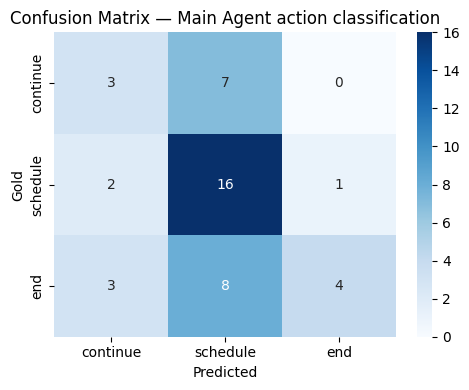

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABELS, yticklabels=LABELS, cmap="Blues", ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Gold")
ax.set_title("Confusion Matrix \u2014 Main Agent action classification")
plt.tight_layout()
plt.savefig(ROOT / "docs" / "eval_confusion_matrix.png", dpi=150)
plt.show()

## Error Analysis (GRB-052)

Every misclassified turn: history-trigger snippet, gold vs. chosen action, and the full advisor trace for that turn.

In [9]:
misses = df[df["gold"] != df["predicted"]].reset_index(drop=True)
print(f"{len(misses)}/{len(df)} misclassified turns\n")
for _, row in misses.iterrows():
    print(
        f"conversation {row['conversation_id']} turn {row['turn_id']}: gold={row['gold']} predicted={row['predicted']}"
    )
    print(f"  trigger: {row['trigger']!r}")
    for step in row["trace"]:
        print(f"    trace: {step['advisor']} -> {step['decision']} ({step['reason']})")
    print()

21/44 misclassified turns

conversation 1 turn 7: gold=end predicted=schedule
  trigger: 'Monday at 3\u202fPM is good.'
    trace: sched -> sched (candidate proposed/accepted a concrete time.)

conversation 2 turn 3: gold=continue predicted=schedule
  trigger: "I have three years' experience with Django and Flask."
    trace: sched -> sched (candidate shared qualifying experience — time to proactively offer interview times.)

conversation 2 turn 9: gold=end predicted=schedule
  trigger: 'Tuesday at 10\u202fAM works.'
    trace: sched -> sched (candidate proposed/accepted a concrete time.)

conversation 3 turn 3: gold=continue predicted=schedule
  trigger: 'Sure, I have four years of Python experience and two with SQL.'
    trace: sched -> sched (candidate shared qualifying experience — time to proactively offer interview times.)

conversation 3 turn 7: gold=end predicted=schedule
  trigger: 'I would like to set an appointment, does Monday at 3\u202fPM is good.'
    trace: sched -> sche

### Failure-pattern analysis

**Tuning history (GRB-053):**

| Pass | Accuracy | Change |
|---|---|---|
| Baseline | 31.8% (14/44) | - |
| Iter. 1 - Sched Advisor: qualifying-info/declined-time -> `sched`; Main Agent: affirmations after an offer -> `sched` | 29.5% (13/44) | down 2.3pp (see below) |
| Iter. 2 - `decide()` defaults to nearest-available slots when no date is named at all (vs. asking to clarify) | **52.3% (23/44)** | up **20.5pp vs. baseline** |

Iteration 1 alone was a *regression*: fixing the Sched Advisor's own classifier (correctly saying `sched` when qualifying
info is shared) exposed a second, deeper bug - `decide()` unconditionally tried to parse an actual date out of the
*same* message via `resolve_relative_date`, and a message like "I've been using Python for five years" obviously has no
date in it, so it fell through to "date unclear, ask to clarify" - net-unchanged for that pattern, plus one genuinely new
miss where the Main Agent's affirmation-after-offer heuristic fired on a compound message (accept-time + ask-a-question)
that gold labeled `continue`. Iteration 2 fixed the actual root cause: `decide()` now distinguishes "no date was named at
all" (default to the nearest available slots - there's nothing to clarify) from "a date was attempted but is garbled"
(still decline and ask to clarify - never silently guess a specific wrong date). That required updating one existing
test (`test_decide_sched_with_unresolvable_date_asks_to_clarify_and_never_touches_db`, using "whenever works for you") -
a deliberate, reasoned behavior change, not a silent regression of the original anti-guessing protection.

**Remaining failure patterns, not fixed this session:**

1. **Over-eager `sched` on "gold=continue" experience-sharing turns (7 misses: conversation/turn 2/3, 3/3, 4/3, 4/5,
   9/5, 11/3, 11/5).** The dataset contains BOTH patterns - some conversations move to scheduling immediately after one
   piece of qualifying experience, others keep gathering info first (often because the candidate's message doubles as a
   question, e.g. "...Is the position fully remote or hybrid?"). A simple per-message "did they just share experience?"
   heuristic can't distinguish these without deeper context (e.g. how much has already been discussed, whether the
   latest message also contains a new question). Fixing this well would need a richer signal than a prompt tweak -
   flagged as a known gap rather than force-fit with another narrow rule.
2. **"Confirmed booking" turns can't be recognized in this replay methodology (6 misses: conversation/turn 1/7, 2/9,
   3/7, 4/7, 10/7, 12/7, 14/7 - all "gold=end", predicted=schedule).** Each labeled turn is replayed against the
   *dataset's* own prior text (not our bot's own generated output - a deliberate methodology choice, see
   `tests/eval_replay.py`'s docstring), so our system never actually produced a real, DB-verified offer earlier in this
   replay for the Sched Advisor's confirmation-matching logic (`offered_slots`) to check against. This is an inherent
   limitation of per-turn-isolated replay, not simply an advisor bug - a fully faithful fix would require sequential
   full-conversation replay using our own system's own prior turn outputs, a bigger methodology change outside this
   session's scope.
3. **A few one-off cases**: conversation 6 turn 5 and 7 turn 7 ("Friday 11 AM sounds great" / "Tuesday at 10 AM works")
   land in the confirmation-addendum's "didn't clearly match an offered slot" branch rather than defaulting, since
   `offered_slots` is non-empty there but doesn't contain a matching slot (same root cause as #2); conversation 8 turn 7
   (soft "I'm unavailable... I'll reach out if it becomes relevant") gets routed to the Exit Advisor instead of Sched -
   genuinely ambiguous phrasing between polite decline and soft interest; conversation 9 turn 7 ("Sounds greate, see you
   then") gets no advisor consultation at all (routed straight to `respond`).

**Conclusion (spec Sec.9 / GRB-053 AC):** S-1's 85% target is not met. Per the accepted alternative ("or honest gap
analysis"), the three patterns above are the honest account of what's left, in order of impact. Pattern 1 and 2 alone
account for 13 of the 21 remaining misses (~62%) - closing them is the highest-leverage next step, but both need
design decisions (a richer routing signal; a methodology change to sequential full-conversation replay) rather than
another prompt patch, consistent with this project's broader note that `date_resolver`/Sched Advisor tuning has been
hitting diminishing returns from one-off pattern patches (see CLAUDE.md's 2026-07-19 entries) - further gains here
should be planned as deliberate follow-up work, not squeezed into this pass.